<h1>Descriptive</h1>

<h1>Unit 1: Visualization</h1>
<div style="text-align: justify">
<h2>$\color{black}{\text{Objetives}}$</h2>
Perform an exploratory and descriptive statistical analysis of the data, and visualize it using different types of graphs.
<br>
<h2>$\color{blue}{\text{1.2 Representative Graphs}}$</h2>
Plots are important aids in data analysis. Although it is impossible to simultaneously plot all the measurements made on several variables and study the configurations, plots of individual variables and plots of pairs of variables can still be very informative. Visual examination of data in one, two, or three dimensions is good statistical practice to visualize the pattern of associations.
</div>

<div style="text-align: justify">
<h3>$\color{blue}{\text{Box Plots}}$</h3>
The boxplot is a graphical technique that displays the distribution of variables. It helps us see the location, skewness, spread, tail length, and outlying points. It is particularly useful in comparing different batches. The boxplot is a graphical representation of the five-number summary. The quartiles displayed in a boxplot cut the data set into four equal parts, which are often called fourths.

Let $x_{(1)} \le \cdots \le x_{(n)}$ denote the order statistics.  
The **depth** of a data value $x_{(i)}$ is defined as
$$
\operatorname{depth}(x_{(i)}) = \min \{ i,\; n - i + 1 \}.
$$

If $n$ is odd, the depth of the median is
$$
\frac{n+1}{2}.
$$

If $n$ is even, $\frac{n+1}{2}$ is fractional. In this case, the median is defined as the average of the two central order statistics:
$$
M = \frac{1}{2}\left\{ x_{(n/2)} + x_{(n/2+1)} \right\}.
$$

The **$F$-spread** is defined as
$$
d_F = F_U - F_L,
$$
where $F_L$ and $F_U$ denote the lower and upper fourths, respectively. Boxplots are very useful tools for comparing batches of data.

The **outside fences** are given by
\begin{align}
F_U + 1.5\, d_F, \tag{1.2} \\
F_L - 1.5\, d_F. \tag{1.3}
\end{align}

Any observation beyond these limits is regarded as an outlier. A boxplot is constructed as follows:
1. Draw a box with edges at $F_L$ and $F_U$ (thus containing 50\% of the data).
2. Draw the median as a solid line and the mean as a dotted line.
3. Draw whiskers from each end of the box to the most extreme data points that are not outliers.
4. Display outliers using symbols such as $\star$ or $\bullet$, depending on whether they lie outside $F_{L,U} \pm 1.5\, d_F$ or $F_{L,U} \pm 3\, d_F$, respectively.  
</div>

<div style="text-align: justify">
<h3>$\color{blue}{\text{Histograms}}$</h3>
Histograms are density estimates. A density estimate gives a good impression of the distribution of the data. In contrast to boxplots, density estimates show possible multimodality of the data. The idea is to locally represent the data density by counting the number of observations in a sequence of consecutive intervals (bins). With origin $x_0$, let $B_j(x_0, h)$ denote the bin of length $h$, which is an element of a bin grid starting at $x_0$:
\[
B_j(x_0, h) = \bigl[\, x_0 + (j-1)h,\; x_0 + jh \,\bigr), 
\qquad j \in \mathbb{Z}.
\]
Here, the notation $[\,\cdot,\cdot\,)$ denotes a left-closed and right-open interval.

Let $\{x_i\}_{i=1}^n$ be an i.i.d.\ sample with density $f$. The histogram estimator is defined by
$$
\hat{f}_h(x)
= n^{-1} h^{-1}
\sum_{j \in \mathbb{Z}}
\sum_{i=1}^n
\mathbf{1}\!\left\{ x_i \in B_j(x_0, h) \right\}
\mathbf{1}\!\left\{ x \in B_j(x_0, h) \right\}.
$$

In last expression, the first indicator function
$$
\mathbf{1}\!\left\{ x_i \in B_j(x_0, h) \right\}
$$
counts the number of observations falling into the bin $B_j(x_0, h)$. The second indicator function localizes these counts around the point $x$. The parameter $h$ is a smoothing (or localizing) parameter that controls the width of the histogram bins. If $h$ is chosen too large, the resulting histogram consists of very wide blocks and exhibits little structure. Conversely, if $h$ is too small, the estimator becomes highly variable and shows many spurious peaks.
Using methods from smoothing methodology, one can determine an optimal binwidth $h$ for $n$ observations:
$$
h_{\mathrm{opt}}
= \left( \frac{24 \sqrt{\pi}}{n} \right)^{1/3}.
$$
Unfortunately, the binwidth $h$ is not the only parameter that determines the shape of the estimator $\hat{f}$. A remedy has been proposed: “Average the shifted histograms!”.
</div>

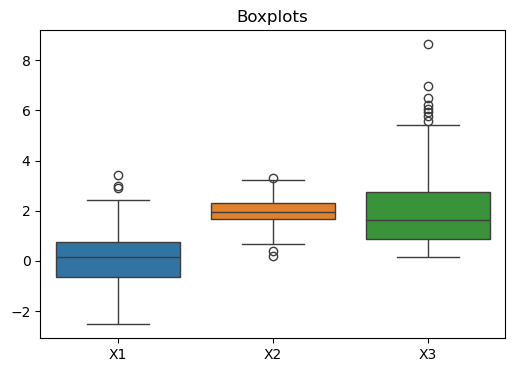

In [2]:
#Examples
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.DataFrame({
    "X1": np.random.normal(0, 1, 500),
    "X2": np.random.normal(2, 0.5, 500),
    "X3": np.random.gamma(2, 1, 500)
})
plt.figure(figsize=(6, 4))
sns.boxplot(data=df)
plt.title("Boxplots")
plt.show()

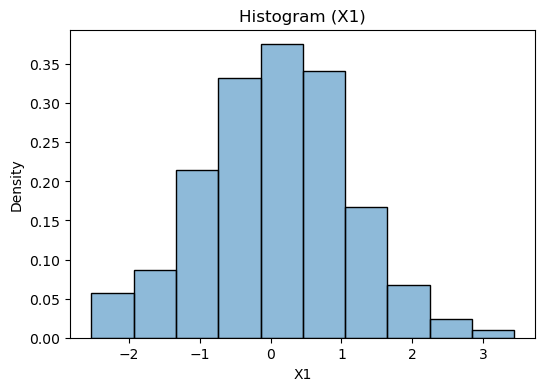

In [4]:
plt.figure(figsize=(6, 4))
sns.histplot(df["X1"], bins=10, stat="density", alpha=0.5)
plt.title("Histogram (X1)")
plt.show()

In [95]:
def AveragedShiftedHistogram(x, bins, n_shifts):
    x = np.asarray(x)
    xmin, xmax = x.min(), x.max()
    h = (xmax - xmin) / bins

    histAvg = np.zeros(bins)

    for k in range(n_shifts):
        shift = k * h / n_shifts
        edges = xmin + shift + np.arange(bins + 1) * h
        hist, _ = np.histogram(x, bins=edges)
        histAvg += hist

    histAvg /= (n_shifts * len(x) * h)
    centers = xmin + (np.arange(bins) + 0.5) * h

    return centers, histAvg

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
n_shifts = 20
bins=30
centers,y=AveragedShiftedHistogram(x,bins,n_shifts)
x=np.random.normal(size=1000)
sns.histplot(x,bins=bins , alpha=0.4,)
plt.plot(centers, y ,color='red')

<div style="text-align: justify">
<h3>$\color{blue}{\text{KDE}}$</h3>
The major difficulties of histogram estimation may be summarized in four critiques:
1. Determination of the binwidth h, which controls the shape of the histogram.
2. The choice of the bin origin $x_0$, which also influences the shape of the histogram to some extent.
3. Loss of information, since observations are replaced by the central point of the interval in which they fall.
4. The underlying density function is often assumed to be smooth, whereas the histogram is not.

Rosenblatt (1956), Whittle (1958), and Parzen (1962) developed an approach that avoids these difficulties. First, a smooth kernel function rather than a box is used as the basic building block. Second, the smooth function is centered directly over each observation. To study this refinement, suppose that $x$ is the center of a bin. The histogram can then be rewritten as
$$
\hat{f}_h(x)
= n^{-1} h^{-1}
\sum_{i=1}^n
\mathbf{1}\!\left(
|x - x_i| \le \frac{h}{2}
\right).
$$

Define the kernel function
$$
K(u) = \mathbf{1}\!\left( |u| \le \tfrac{1}{2} \right).
$$
Then last expression can be written as
$$
\hat{f}_h(x)
= n^{-1} h^{-1}
\sum_{i=1}^n
K\!\left( \frac{x - x_i}{h} \right).
$$

Last Equation represents the general form of the kernel density estimator.
</div>

<table>
  <tr>
    <th>Kernel</th>
    <th>K(u)</th>
  </tr>
  <tr>
    <td>Uniform</td>
    <td>$\frac{1}{2}\mathbf{1}(|u|\leq 1)$</td>
  </tr>
  <tr>
    <td>Triangular</td>
    <td>$(1-|u|)\mathbf{1}(|u|\leq 1)$</td>
  </tr>
  <tr>
    <td>Epanechnikov</td>
    <td>$\frac{3}{4}(1-u^2)\mathbf{1}(|u|\leq 1)$</td>
  </tr>
  <tr>
    <td>Quartic (Biweight)</td>
    <td>$\frac{15}{16}(1-u^2)^2\mathbf{1}(|u|\leq 1)$</td>
  </tr>
  <tr>
    <td>Gaussian</td>
    <td>$\frac{1}{\sqrt{2\pi}}e^{-u^2/2}$</td>
  </tr>
</table>

<div style="text-align: justify">
Different kernels generate different shapes of the estimated density. The most important parameter is the bandwidth $h$, which can be optimized, for example, by cross-validation. The cross-validation method minimizes the integrated squared error. This measure of discrepancy is based on the squared difference
$$
\{\hat f_h(x) - f(x)\}^2 .
$$

Averaging these squared deviations over a grid of points $\{x_l\}_{l=1}^{L}$ leads to
$$
L^{-1} \sum_{l=1}^{L} \left\{ \hat f_h(x_l) - f(x_l) \right\}^2 .
$$

Asymptotically, if the grid size tends to zero, this expression converges to the integrated squared error
$$
\int \left\{ \hat f_h(x) - f(x) \right\}^2 \, dx .
$$

In practice, the method consists of selecting a bandwidth that minimizes the cross-validation function
$$
\int \hat f_h^2(x)\, dx
\;-\;
\frac{2}{n} \sum_{i=1}^{n} \hat f_{h,i}(x_i),
$$
where $\hat f_{h,i}$ denotes the density estimator obtained by leaving out the $i$-th observation. Several alternative bandwidth selection methods exist. One of the fastest approaches is based on a reference distribution. The idea of using the normal distribution as a reference. The resulting choice of $h$ is known as the *rule of thumb*. For the Gaussian kernel and a normal reference distribution, the rule of thumb bandwidth is given by
$$
h_G = 1.06\, \hat\sigma\, n^{-1/5}.
$$

where
$$
\hat{\sigma}=\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\left(x_i - \bar{x}\right)^2}
$$
denotes the sample standard deviation. This choice of bandwidth $h_G$ optimizes the integrated squared distance between the kernel density estimator and the true underlying density. For the quartic kernel, the modified rule of thumb is given by
$$
h_Q = 2.62 \cdot h_G .
$$

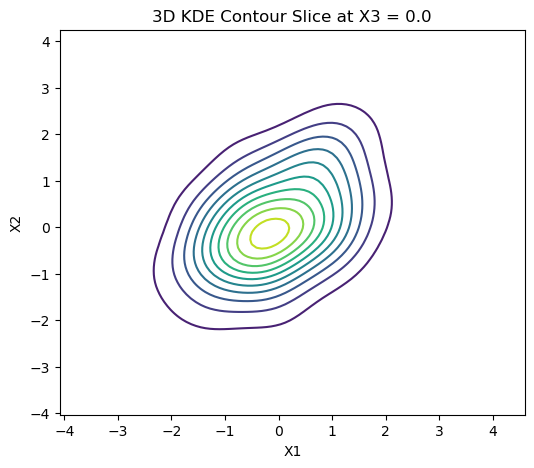

In [1]:
#Example:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity


np.random.seed(0)
X = np.random.multivariate_normal(mean=[0, 0, 0],cov=[[1, 0.5, 0.3],[0.5, 1, 0.2],[0.3, 0.2, 1]],size=500)


kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
kde.fit(X)

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading dataset
cancer = load_breast_cancer()

In [6]:
df=pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target']=cancer.target #0 = malignant, 1 = beningn
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

<Axes: xlabel='mean radius', ylabel='Density'>

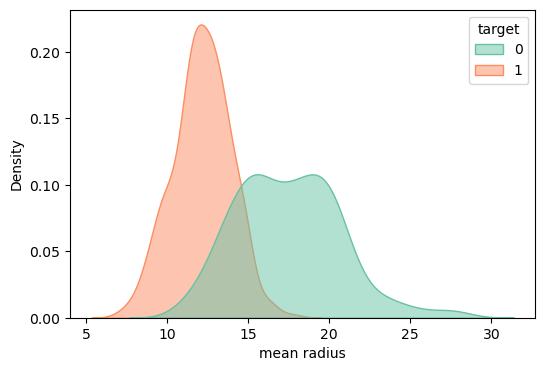

In [12]:
features = 'mean radius'
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x=features, hue='target', fill=True, common_norm=False, alpha=0.5, palette='Set2')

<Axes: xlabel='mean radius', ylabel='mean texture'>

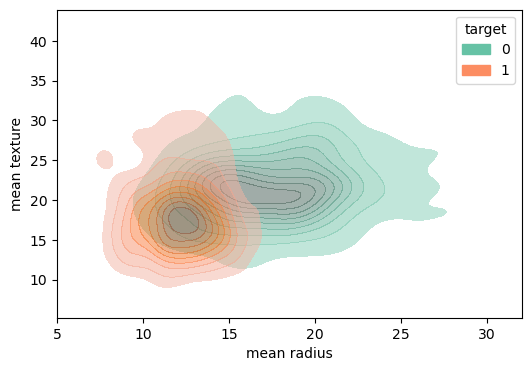

In [13]:
features = ['mean radius','mean texture']
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x=features[0],y=features[1], hue='target', fill=True, common_norm=False, alpha=0.5, palette='Set2')

<div style="text-align: justify">
<h3>$\color{blue}{\text{Scatterplots}}$</h3>
Scatterplots are bivariate or trivariate plots of variables against each other. They help us understand relationships among the variables of a data set. A downward-sloping scatter indicates that as we increase the variable on the horizontal axis, the variable on the vertical axis decreases. An analogous statement can be made for upward-sloping scatters.

If we want to draw all possible two-dimensional scatterplots for the variables, we can create a so-called draftman’s plot (named after a draftman who prepares drafts for parliamentary discussions). Similar to a draftman’s plot, the scatterplot matrix helps in creating new ideas and in building knowledge about dependencies and structure.
</div>

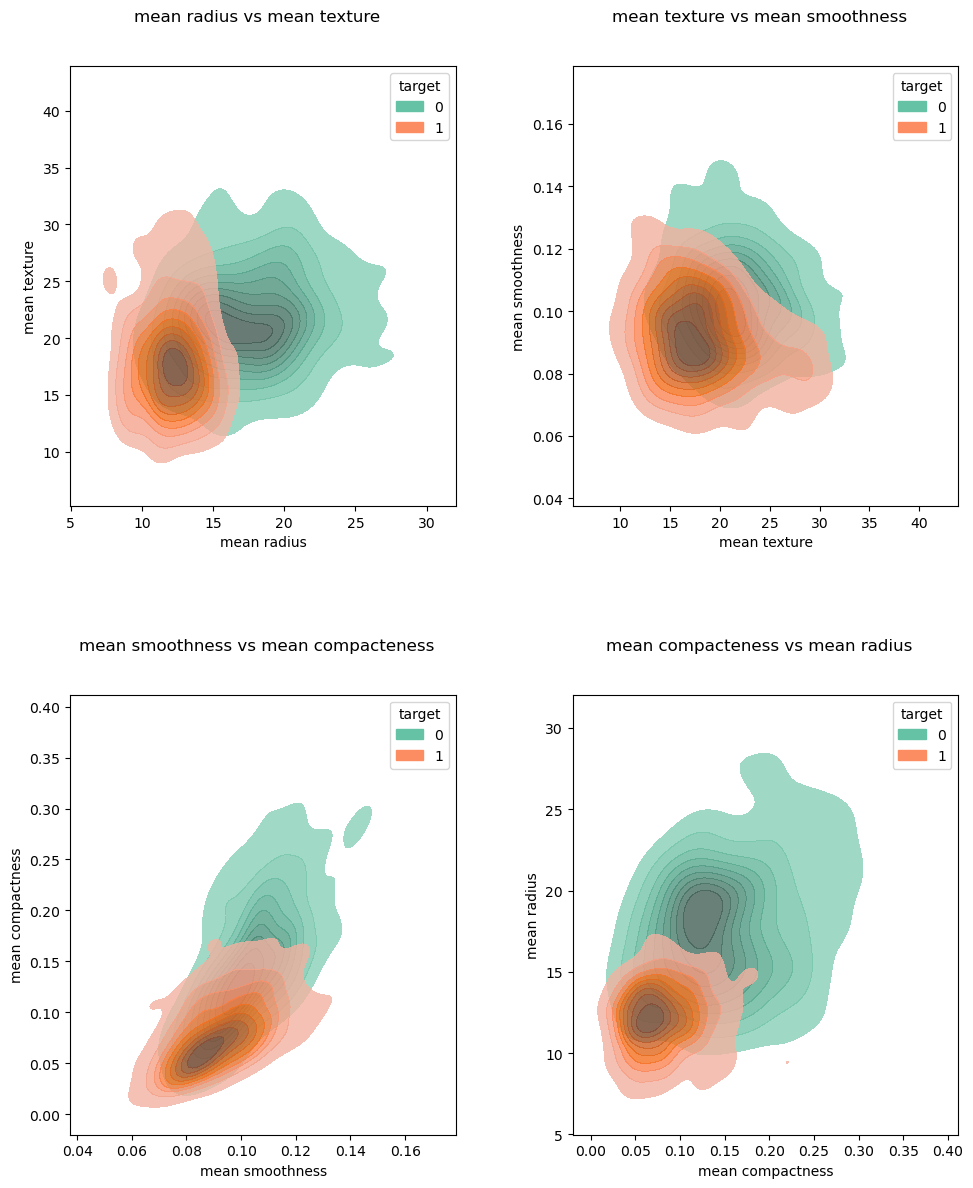

In [42]:
features = ['mean radius','mean texture','mean smoothness','mean compactness']

fig = plt.figure(figsize=(10, 12))
subfigs = fig.subfigures(2, 2, wspace=0.01, hspace=0.1)

ax00 = subfigs[0, 0].subplots()
ax01 = subfigs[0, 1].subplots()
ax10 = subfigs[1, 0].subplots()
ax11 = subfigs[1, 1].subplots()

subfigs[0, 0].suptitle('mean radius vs mean texture')
sns.kdeplot(data=df, x=features[0], y=features[1],
            hue='target', fill=True, common_norm=False,
            alpha=0.8, palette='Set2', ax=ax00)

subfigs[0, 1].suptitle('mean texture vs mean smoothness')
sns.kdeplot(data=df, x=features[1], y=features[2],
            hue='target', fill=True, common_norm=False,
            alpha=0.8, palette='Set2', ax=ax01)

subfigs[1, 0].suptitle('mean smoothness vs mean compacteness')
sns.kdeplot(data=df, x=features[2], y=features[3],
            hue='target', fill=True, common_norm=False,
            alpha=0.8, palette='Set2', ax=ax10)

subfigs[1, 1].suptitle('mean compacteness vs mean radius')
sns.kdeplot(data=df, x=features[3], y=features[0],
            hue='target', fill=True, common_norm=False,
            alpha=0.8, palette='Set2', ax=ax11)

plt.show()


In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
from sklearn.covariance import MinCovDet
from sklearn.covariance import EmpiricalCovariance

data = fetch_openml(name="diabetes", as_frame=True)
df = data.frame
df

/home/marcos/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name diabetes exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=37
- version 5, status: active
  url: https://www.openml.org/search?type=data&id=42608

  warn(warning_msg)


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,tested_negative
764,2,122,70,27,0,36.8,0.340,27,tested_negative
765,5,121,72,23,112,26.2,0.245,30,tested_negative
766,1,126,60,0,0,30.1,0.349,47,tested_positive


In [51]:
df['pres'].unique()

array([ 72,  66,  64,  40,  74,  50,   0,  70,  96,  92,  80,  60,  84,
        30,  88,  90,  94,  76,  82,  75,  58,  78,  68, 110,  56,  62,
        85,  86,  48,  44,  65, 108,  55, 122,  54,  52,  98, 104,  95,
        46, 102, 100,  61,  24,  38, 106, 114])

Text(0.5, 1.0, 'Parallel coordinates plot')

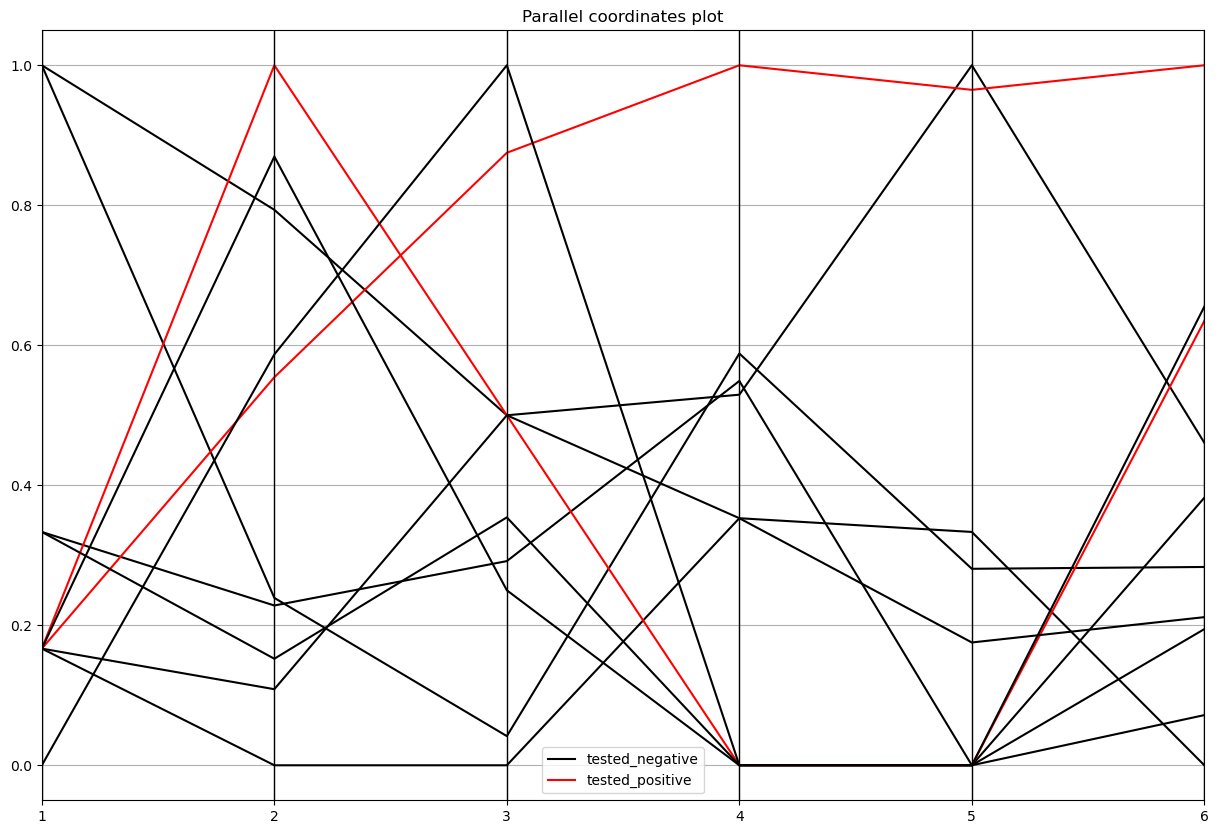

In [47]:
x = df[['preg', 'plas', 'pres', 'skin', 'insu', 'mass']]
x = x[95:105]
c = df['class'][95:105]

y = (x - x.min())/(x.max() - x.min())
y.loc[:, 6] = c
y.columns = ["1", "2", "3", "4", "5", "6", "c"]

fig, ax = plt.subplots(figsize = (15, 10))
pd.plotting.parallel_coordinates(y, "c", color = ["black", "r"])
ax.legend()
plt.title("Parallel coordinates plot")

Text(0.5, 1.0, 'Parallel coordinates plot')

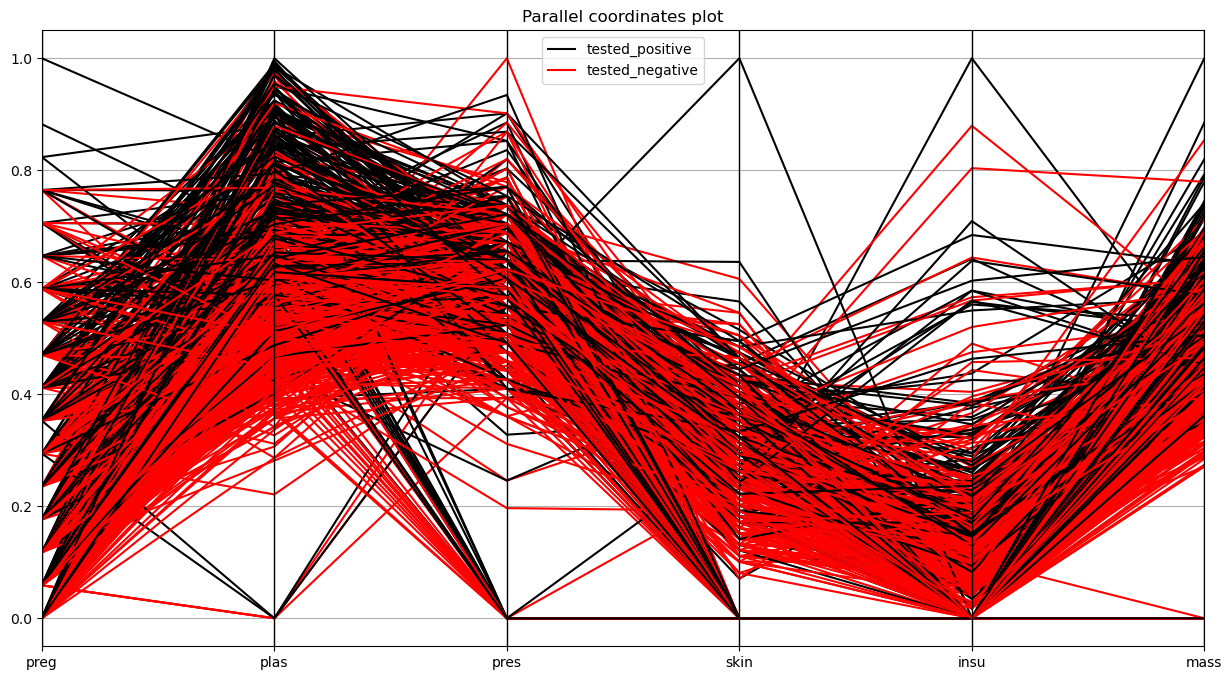

In [48]:
x = df[['preg', 'plas', 'pres', 'skin', 'insu', 'mass']]
c = df['class']

y = (x - x.min())/(x.max() - x.min())
y.loc[:, 6] = c
y.columns = ["1", "2", "3", "4", "5", "6", "c"]

fig, ax = plt.subplots(figsize = (15, 8))
pd.plotting.parallel_coordinates(y, "c", color = ["black", "r"])
plt.xticks(ticks=[0,1,2,3,4,5],labels=['preg', 'plas', 'pres', 'skin', 'insu', 'mass'])
ax.legend()
plt.title("Parallel coordinates plot")